# Explore GEMS O3 Retrieval Uncertainty

This notebook is a read-only diagnostic for the GEMS total column ozone NetCDF products. It does **not** modify the existing CSV/pickle preprocessing or modeling pipeline.

Goal: inspect whether the O3 product contains a measurement/retrieval uncertainty variable analogous to `ColumnUncertainty` in other GEMS products, then examine its spatial pattern and relation to viewing geometry.


In [19]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="xarray")

GEMS_TCO_PATH = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
sys.path.append(str(GEMS_TCO_PATH))

from GEMS_TCO import configuration as config
from GEMS_TCO import data_preprocess as dmbh

RAW_ROOT = Path("/Volumes/Backup Plus/GEMS_UNZIPPED")
OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Same broad region used in the tile/nadir discussion.
LAT_RANGE = (-3.0, 7.0)
LON_RANGE = (111.0, 131.0)

# Existing modeling region, useful for comparison with prior EDA notebooks.
FOCUSED_LAT_RANGE = (-3.0, 2.0)
FOCUSED_LON_RANGE = (121.0, 131.0)

ACCEPTABLE_FLAGS = [0, 2]

print(f"RAW_ROOT exists: {RAW_ROOT.exists()} -> {RAW_ROOT}")
print(f"Output directory: {OUT_DIR}")


RAW_ROOT exists: True -> /Volumes/Backup Plus/GEMS_UNZIPPED
Output directory: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration


## Pick a Sample O3 NetCDF File

The paths below follow the same raw-data layout used by `step2_truncate_cvs_pickle_by_monthyear_020226.ipynb`. You can change `SAMPLE_FILE` manually if you want a different date/slot.


In [20]:
def month_day_suffix(month: int, year: int | None = None) -> str:
    if month == 2:
        if year == 2024:
            return "0129"
        return "0128"
    return "0131" if month in [1, 3, 5, 7, 8, 10, 12] else "0130"


def candidate_file(year: int, month: int, day: int, slot_hour: int) -> Path:
    suffix = month_day_suffix(month, year)
    return RAW_ROOT / f"{year}{month:02d}{suffix}" / f"{year}{month:02d}{day:02d}_{slot_hour:02d}45.nc"

CANDIDATES = [
    candidate_file(2025, 7, 14, 2),
    candidate_file(2025, 7, 1, 0),
    candidate_file(2024, 7, 1, 0),
    candidate_file(2023, 7, 1, 0),
    candidate_file(2022, 7, 1, 0),
]

SAMPLE_FILE = next((p for p in CANDIDATES if p.exists() and not p.name.startswith("._")), None)
if SAMPLE_FILE is None:
    raise FileNotFoundError("No sample GEMS O3 NetCDF file found. Update RAW_ROOT or CANDIDATES.")

print("Using sample file:")
print(SAMPLE_FILE)


Using sample file:
/Volumes/Backup Plus/GEMS_UNZIPPED/2025070131/20250714_0245.nc


## List Groups and Candidate Uncertainty Variables

For this O3 product, the uncertainty-like variable appears to be `EstimatedError` in `Data Fields`.


In [21]:
def summarize_nc_variables(file_path: Path) -> pd.DataFrame:
    rows = []
    with Dataset(file_path) as ds:
        for group_name, group in ds.groups.items():
            for var_name, var in group.variables.items():
                attrs = {name: getattr(var, name) for name in var.ncattrs()}
                rows.append({
                    "group": group_name,
                    "variable": var_name,
                    "dims": tuple(var.dimensions),
                    "shape": tuple(var.shape),
                    "dtype": str(var.dtype),
                    "units": attrs.get("units", ""),
                    "long_name": attrs.get("long_name", attrs.get("Title", "")),
                    "description": attrs.get("description", ""),
                })
    return pd.DataFrame(rows)

var_summary = summarize_nc_variables(SAMPLE_FILE)
print(var_summary.to_string(index=False, max_colwidth=80))

uncertainty_like = var_summary[
    var_summary["variable"].str.contains("uncert|error|estimated", case=False, regex=True)
].copy()
print("\nUncertainty/error-like variables:")
print(uncertainty_like.to_string(index=False, max_colwidth=100))


             group                  variable                               dims               shape   dtype                                     units                                                                        long_name description
       Data Fields           AveragingKernel (nlayer2, nlayer2, spatial, image) (11, 11, 2048, 695) float32                                  unitless                                                          Averaging Kernel Matrix            
       Data Fields             CloudPressure                   (spatial, image)         (2048, 695) float32                                       hPa                               Cloud Centroid Pressure from GEMS L2 cloud prodcut            
       Data Fields            ColumnAmountO3                   (spatial, image)         (2048, 695) float32                                        DU                                                        Best Total Ozone Solution            
       Data Fields DegreesOf

## Load O3, EstimatedError, Quality Flags, and Geometry

This mirrors the existing extraction logic, but adds `EstimatedError`, `ViewingZenithAngle`, and `SolarZenithAngle` for diagnostic analysis.


In [22]:
def load_o3_uncertainty_frame(file_path: Path) -> pd.DataFrame:
    geo_vars = ["Latitude", "Longitude", "Time", "ViewingZenithAngle", "SolarZenithAngle", "GroundPixelQualityFlags"]
    data_vars = ["ColumnAmountO3", "EstimatedError", "FinalAlgorithmFlags"]

    with xr.open_dataset(file_path, group="Geolocation Fields") as geo, xr.open_dataset(file_path, group="Data Fields") as data:
        available_geo = [v for v in geo_vars if v in geo]
        available_data = [v for v in data_vars if v in data]

        missing_geo = sorted(set(geo_vars) - set(available_geo))
        missing_data = sorted(set(data_vars) - set(available_data))
        if missing_geo:
            print("Missing geolocation variables:", missing_geo)
        if missing_data:
            print("Missing data variables:", missing_data)

        geo_df = geo[available_geo].to_dataframe().reset_index(drop=True)
        data_df = data[available_data].to_dataframe().reset_index(drop=True)

    df = pd.concat([geo_df, data_df], axis=1)

    numeric_cols = [
        "Latitude", "Longitude", "Time", "ViewingZenithAngle", "SolarZenithAngle",
        "GroundPixelQualityFlags", "ColumnAmountO3", "EstimatedError", "FinalAlgorithmFlags",
    ]
    for col in numeric_cols:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

raw_df = load_o3_uncertainty_frame(SAMPLE_FILE)
print(raw_df.head())
print("\nShape:", raw_df.shape)
print("Columns:", raw_df.columns.tolist())
print("\nMissing counts:")
print(raw_df.isna().sum().to_string())


    Latitude   Longitude                 Time  ViewingZenithAngle  \
0  45.799629  144.022263  1752461107606000000           54.955620   
1  45.795853  143.921539  1752461110160000000           54.923634   
2  45.792168  143.820419  1752461112714000000           54.891781   
3  45.788342  143.719833  1752461115268000000           54.860096   
4  45.784710  143.619553  1752461117822999936           54.828842   

   SolarZenithAngle  GroundPixelQualityFlags  ColumnAmountO3  EstimatedError  \
0         24.351530                      0.0       99.675858        2.347075   
1         24.338457                      0.0       91.899521        2.462258   
2         24.325653                      0.0       93.160980        2.392979   
3         24.312981                      0.0       89.659729        2.425512   
4         24.300745                      0.0       94.304985        2.485700   

   FinalAlgorithmFlags  
0                129.0  
1                129.0  
2                129.0  
3   

## Region and Quality Filtering

This does not save any processed file. It only reproduces the filtering idea used in the current pipeline so we can inspect uncertainty values for pixels that would enter the analysis.


In [23]:
def filter_region_quality(df: pd.DataFrame, lat_range=LAT_RANGE, lon_range=LON_RANGE, flags=ACCEPTABLE_FLAGS) -> pd.DataFrame:
    out = df.copy()
    out = out[
        out["Latitude"].between(lat_range[0], lat_range[1])
        & out["Longitude"].between(lon_range[0], lon_range[1])
    ]
    out = out.dropna(subset=["Latitude", "Longitude", "ColumnAmountO3", "EstimatedError", "FinalAlgorithmFlags"])

    # Existing preprocessing excludes fill/bad O3 values with ColumnAmountO3 < 1000.
    out = out[out["ColumnAmountO3"] < 1000]
    out["is_good_flag"] = out["FinalAlgorithmFlags"].isin(flags)
    return out

region_df = filter_region_quality(raw_df)
good_df = region_df[region_df["is_good_flag"]].copy()
assert set(good_df["FinalAlgorithmFlags"].dropna().unique()).issubset(set(ACCEPTABLE_FLAGS))

print("Region rows:", len(region_df))
print(f"Good-flag rows, FinalAlgorithmFlags in {ACCEPTABLE_FLAGS}:", len(good_df))
print("Good fraction:", len(good_df) / len(region_df) if len(region_df) else np.nan)
print("Good flags present:", sorted(good_df["FinalAlgorithmFlags"].dropna().unique().tolist()))
print("\nFinalAlgorithmFlags counts in region:")
print(region_df["FinalAlgorithmFlags"].value_counts(dropna=False).sort_index().to_string())

summary_cols = ["ColumnAmountO3", "EstimatedError", "ViewingZenithAngle", "SolarZenithAngle"]
print("\nGood-flag summary:")
print(good_df[summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_string())


Region rows: 144132
Good-flag rows, FinalAlgorithmFlags in [0, 2]: 135123
Good fraction: 0.9374947964365998
Good flags present: [0.0, 2.0]

FinalAlgorithmFlags counts in region:
FinalAlgorithmFlags
0.0      42571
2.0      92552
129.0     3482
131.0     5527

Good-flag summary:
       ColumnAmountO3  EstimatedError  ViewingZenithAngle  SolarZenithAngle
count   135123.000000   135123.000000       135123.000000     135123.000000
mean       247.682327        1.288467           10.146517         25.338055
std          6.677272        0.779293            5.433295          3.648980
min        227.429062        0.531254            0.036283         16.527679
1%         234.211472        0.620589            1.221315         17.649189
5%         237.334743        0.684817            2.434155         19.130801
50%        247.132904        0.877702            9.446552         25.528347
95%        260.372946        3.064772           19.423029         31.233118
99%        263.935582        3.454518 

## Basic Distributions and Geometry Relationships

Use these quick plots to see whether `EstimatedError` varies systematically with viewing/solar geometry.


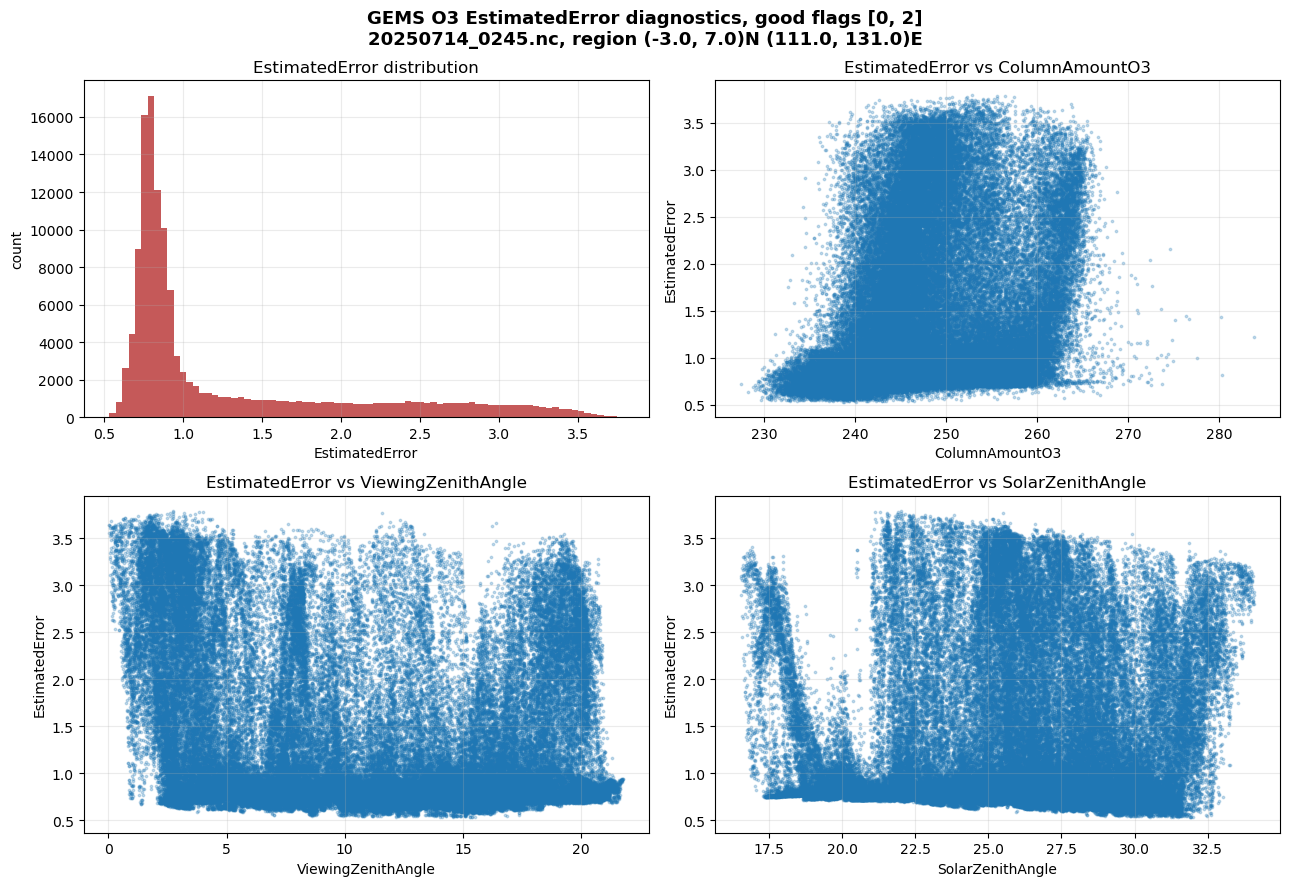

                    EstimatedError  ColumnAmountO3  ViewingZenithAngle  SolarZenithAngle
EstimatedError               1.000           0.246              -0.164             0.135
ColumnAmountO3               0.246           1.000               0.225            -0.317
ViewingZenithAngle          -0.164           0.225               1.000             0.634
SolarZenithAngle             0.135          -0.317               0.634             1.000


In [24]:
plot_df = good_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f"GEMS O3 EstimatedError diagnostics, good flags {ACCEPTABLE_FLAGS}\n{SAMPLE_FILE.name}, region {LAT_RANGE}N {LON_RANGE}E", fontsize=13, fontweight="bold")

axes[0, 0].hist(plot_df["EstimatedError"].dropna(), bins=80, color="firebrick", alpha=0.75)
axes[0, 0].set_title("EstimatedError distribution")
axes[0, 0].set_xlabel("EstimatedError")
axes[0, 0].set_ylabel("count")

axes[0, 1].scatter(plot_df["ColumnAmountO3"], plot_df["EstimatedError"], s=3, alpha=0.25)
axes[0, 1].set_title("EstimatedError vs ColumnAmountO3")
axes[0, 1].set_xlabel("ColumnAmountO3")
axes[0, 1].set_ylabel("EstimatedError")

axes[1, 0].scatter(plot_df["ViewingZenithAngle"], plot_df["EstimatedError"], s=3, alpha=0.25)
axes[1, 0].set_title("EstimatedError vs ViewingZenithAngle")
axes[1, 0].set_xlabel("ViewingZenithAngle")
axes[1, 0].set_ylabel("EstimatedError")

axes[1, 1].scatter(plot_df["SolarZenithAngle"], plot_df["EstimatedError"], s=3, alpha=0.25)
axes[1, 1].set_title("EstimatedError vs SolarZenithAngle")
axes[1, 1].set_xlabel("SolarZenithAngle")
axes[1, 1].set_ylabel("EstimatedError")

for ax in axes.ravel():
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(OUT_DIR / f"estimated_error_basic_{SAMPLE_FILE.stem}.png", dpi=130, bbox_inches="tight")
plt.show()

corr_cols = ["EstimatedError", "ColumnAmountO3", "ViewingZenithAngle", "SolarZenithAngle"]
print(plot_df[corr_cols].corr().round(3).to_string())


## Spatial Map for One Orbit

This shows whether the uncertainty is smaller near the GEMS sub-satellite point region or follows another spatial pattern.


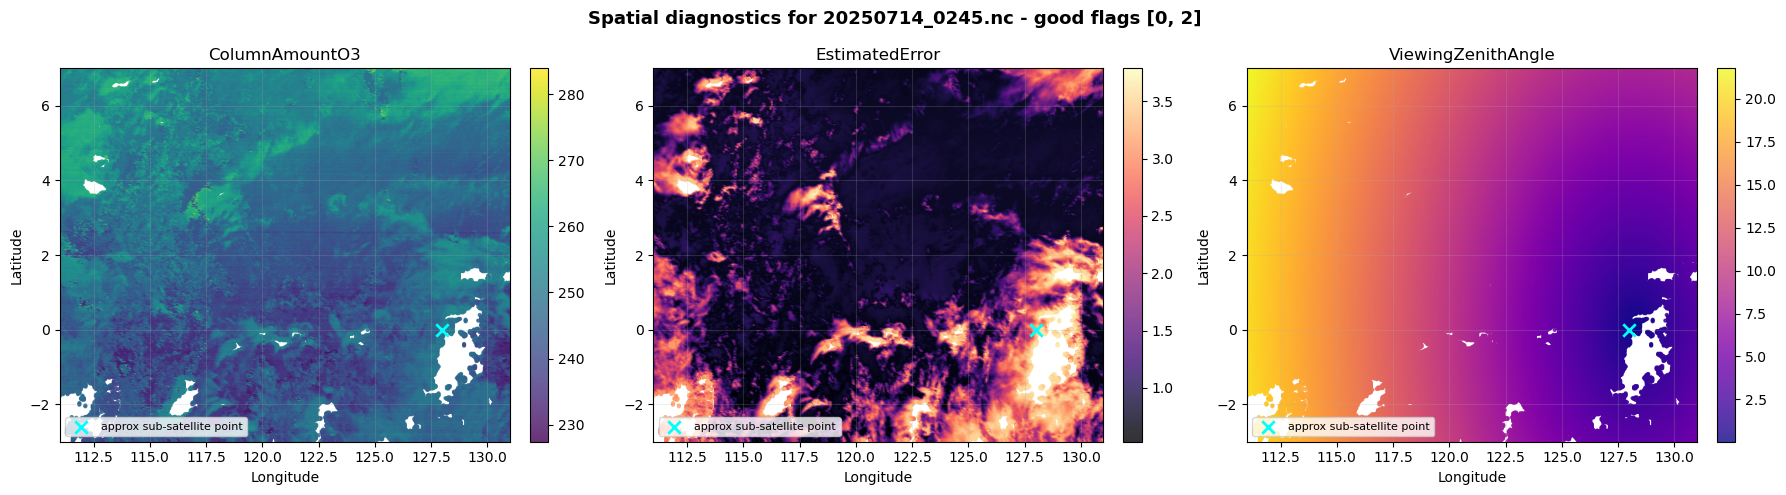

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Spatial diagnostics for {SAMPLE_FILE.name} - good flags {ACCEPTABLE_FLAGS}", fontsize=13, fontweight="bold")

for ax, col, title, cmap in [
    (axes[0], "ColumnAmountO3", "ColumnAmountO3", "viridis"),
    (axes[1], "EstimatedError", "EstimatedError", "magma"),
    (axes[2], "ViewingZenithAngle", "ViewingZenithAngle", "plasma"),
]:
    sc = ax.scatter(good_df["Longitude"], good_df["Latitude"], c=good_df[col], s=4, cmap=cmap, alpha=0.8)
    ax.scatter([128], [0], marker="x", c="cyan", s=80, linewidths=2, label="approx sub-satellite point")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(LON_RANGE)
    ax.set_ylim(LAT_RANGE)
    ax.legend(fontsize=8, loc="best")
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUT_DIR / f"estimated_error_spatial_{SAMPLE_FILE.stem}.png", dpi=130, bbox_inches="tight")
plt.show()


## Tile-Level Summary

This matches the 4x8 tile view used in the short-scale variability discussion. It summarizes median `EstimatedError` and median `ViewingZenithAngle` within each tile for one orbit.


 tile_y  tile_x    n  median_error  mean_error  median_vza  median_sza  median_o3
      0       0 2516      2.398286    2.277088   18.817385   32.511433 245.067566
      0       1 4169      0.958841    1.212837   15.978996   31.379099 242.250290
      0       2 3800      0.944214    1.303790   12.955674   29.980341 241.953720
      0       3 4429      0.873987    1.229166   10.249757   28.843431 241.355225
      0       4 4139      1.351731    1.536486    7.514707   27.635651 241.570831
      0       5 4479      1.857211    1.900475    4.690421   26.651064 242.119202
      0       6 3415      2.837913    2.757870    2.758468   25.945646 246.684387
      0       7 3643      2.794796    2.379903    3.116160   25.211971 245.641327
      1       0 4347      1.674493    1.698216   18.818483   31.009581 248.026932
      1       1 4368      0.802693    0.959553   15.908650   29.546108 244.782532
      1       2 4388      0.757784    0.851711   12.984008   28.138128 243.205627
      1       3 

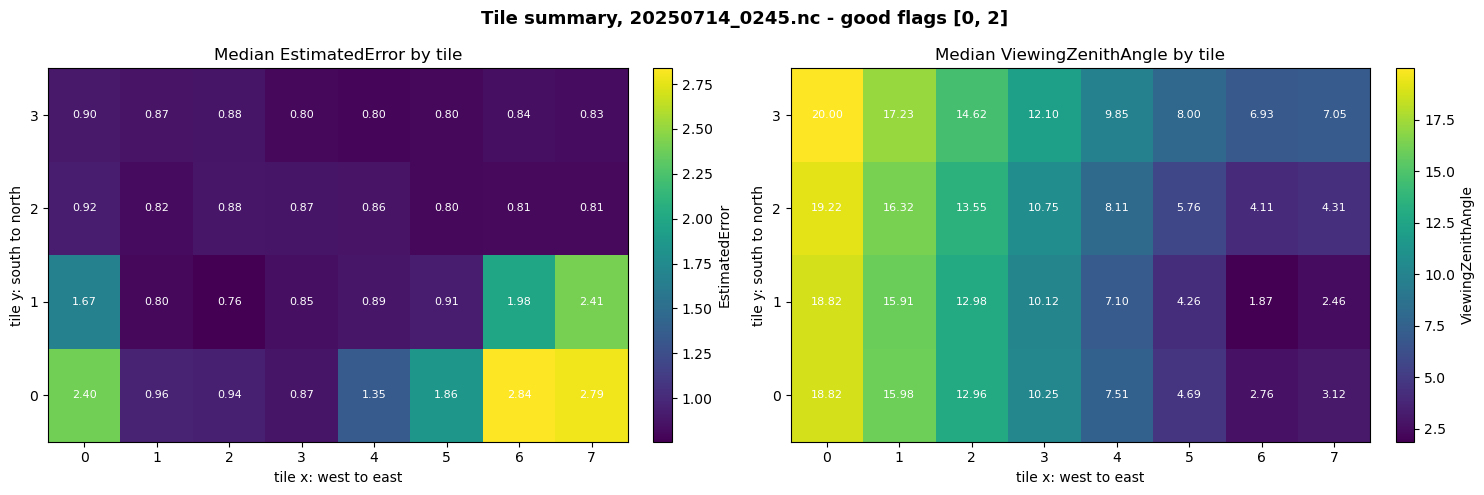

In [26]:
def add_tile_indices(df: pd.DataFrame, lat_range=LAT_RANGE, lon_range=LON_RANGE, ny=4, nx=8) -> pd.DataFrame:
    out = df.copy()
    lat_edges = np.linspace(lat_range[0], lat_range[1], ny + 1)
    lon_edges = np.linspace(lon_range[0], lon_range[1], nx + 1)

    out["tile_y"] = pd.cut(out["Latitude"], bins=lat_edges, labels=False, include_lowest=True)
    out["tile_x"] = pd.cut(out["Longitude"], bins=lon_edges, labels=False, include_lowest=True)
    return out.dropna(subset=["tile_y", "tile_x"]).assign(
        tile_y=lambda d: d["tile_y"].astype(int),
        tile_x=lambda d: d["tile_x"].astype(int),
    )

tiled_df = add_tile_indices(good_df)

tile_summary = (
    tiled_df
    .groupby(["tile_y", "tile_x"])
    .agg(
        n=("EstimatedError", "size"),
        median_error=("EstimatedError", "median"),
        mean_error=("EstimatedError", "mean"),
        median_vza=("ViewingZenithAngle", "median"),
        median_sza=("SolarZenithAngle", "median"),
        median_o3=("ColumnAmountO3", "median"),
    )
    .reset_index()
)

print(tile_summary.to_string(index=False))

ny, nx = 4, 8
error_grid = tile_summary.pivot(index="tile_y", columns="tile_x", values="median_error").reindex(index=range(ny), columns=range(nx))
vza_grid = tile_summary.pivot(index="tile_y", columns="tile_x", values="median_vza").reindex(index=range(ny), columns=range(nx))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"Tile summary, {SAMPLE_FILE.name} - good flags {ACCEPTABLE_FLAGS}", fontsize=13, fontweight="bold")

for ax, grid, title, cbar_label in [
    (axes[0], error_grid, "Median EstimatedError by tile", "EstimatedError"),
    (axes[1], vza_grid, "Median ViewingZenithAngle by tile", "ViewingZenithAngle"),
]:
    im = ax.imshow(grid.values, origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("tile x: west to east")
    ax.set_ylabel("tile y: south to north")
    ax.set_xticks(range(nx))
    ax.set_yticks(range(ny))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    for y in range(ny):
        for x in range(nx):
            val = grid.loc[y, x]
            if pd.notna(val):
                ax.text(x, y, f"{val:.2f}", ha="center", va="center", fontsize=8, color="white")

plt.tight_layout()
plt.savefig(OUT_DIR / f"estimated_error_tile_{SAMPLE_FILE.stem}.png", dpi=130, bbox_inches="tight")
plt.show()


## Optional: Batch Summary Across July Files

Set `RUN_BATCH = True` to scan multiple July files and summarize `EstimatedError` by year, slot, and tile. This can take several minutes because it reads many raw NetCDF files.


In [28]:
RUN_BATCH = True
BATCH_YEARS = [2022, 2023, 2024, 2025]
BATCH_YEARS = [2025]
BATCH_MONTH = 7
MAX_FILES_PER_YEAR = None  # set e.g. 16 for a quick smoke test


def file_list_for_month(year: int, month: int) -> list[Path]:
    inst = dmbh.file_path_list(year, month, str(RAW_ROOT) + "/")
    return [Path(p) for p in inst.file_names_july24() if Path(p).exists() and not Path(p).name.startswith("._")]


def summarize_uncertainty_file(file_path: Path, year: int, slot: int) -> pd.DataFrame:
    df = load_o3_uncertainty_frame(file_path)
    df = filter_region_quality(df)
    df = df[df["is_good_flag"]].copy()
    if df.empty:
        return pd.DataFrame()

    df = add_tile_indices(df)
    out = (
        df.groupby(["tile_y", "tile_x"])
        .agg(
            n=("EstimatedError", "size"),
            median_error=("EstimatedError", "median"),
            mean_error=("EstimatedError", "mean"),
            median_vza=("ViewingZenithAngle", "median"),
            median_sza=("SolarZenithAngle", "median"),
        )
        .reset_index()
    )
    out["year"] = year
    out["slot"] = slot
    out["file"] = file_path.name
    return out

if RUN_BATCH:
    batch_rows = []
    for year in BATCH_YEARS:
        files = file_list_for_month(year, BATCH_MONTH)
        if MAX_FILES_PER_YEAR is not None:
            files = files[:MAX_FILES_PER_YEAR]
        print(f"{year}-{BATCH_MONTH:02d}: {len(files)} files")

        for i, file_path in enumerate(files):
            slot = i % 8
            try:
                batch_rows.append(summarize_uncertainty_file(file_path, year, slot))
            except Exception as exc:
                print(f"  skip {file_path.name}: {exc}")

    batch_summary = pd.concat(batch_rows, ignore_index=True) if batch_rows else pd.DataFrame()
    batch_path = OUT_DIR / f"estimated_error_tile_summary_july_{'_'.join(map(str, BATCH_YEARS))}.csv"
    batch_summary.to_csv(batch_path, index=False)
    print("Saved:", batch_path)
    display(batch_summary.head())
else:
    print("Batch scan skipped. Set RUN_BATCH=True to run it.")


2025-07: 247 files
Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration/estimated_error_tile_summary_july_2025.csv


,tile_y,tile_x,n,median_error,mean_error,median_vza,median_sza,year,slot,file
0,0,0,4273,1.284462,1.151408,18.934780,57.224003,2025,0,20250701_0045.nc
1,0,1,4035,1.315235,1.232370,15.990589,55.338642,2025,0,20250701_0045.nc
2,0,2,4382,0.885081,0.884957,13.141589,53.612244,2025,0,20250701_0045.nc
3,0,3,4571,0.759056,0.827333,10.262650,51.827278,2025,0,20250701_0045.nc
4,0,4,4388,0.983299,1.118121,7.467066,50.085587,2025,0,20250701_0045.nc


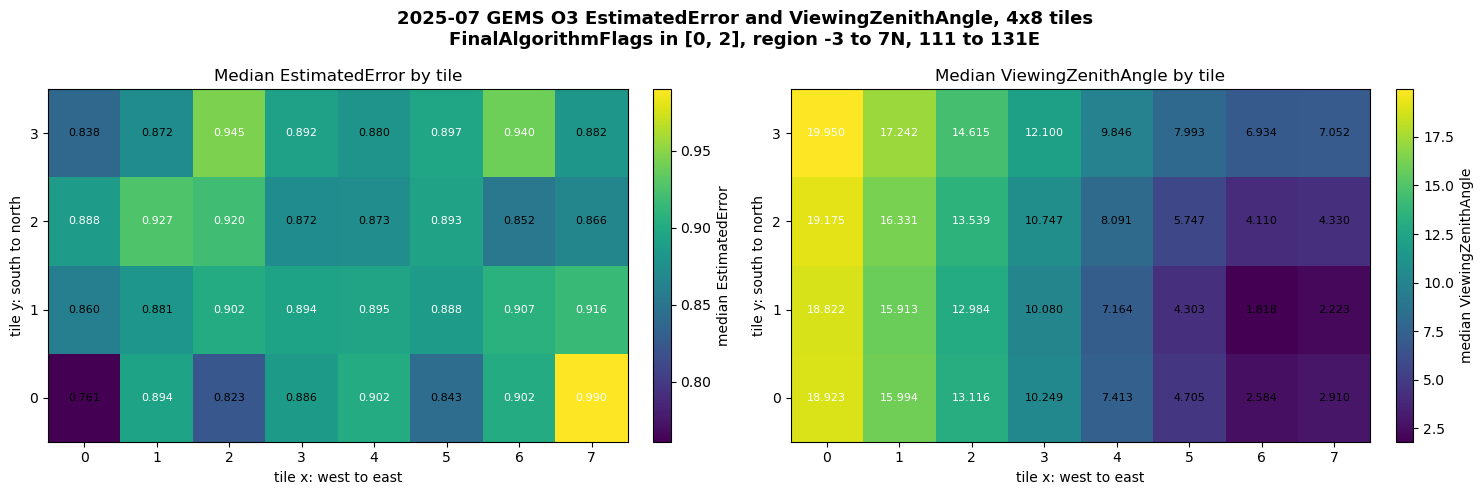

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration/estimated_error_tile_july_2025_4x8.png
 tile_y  tile_x  n_files  total_n  median_error_july  mean_error_july  median_vza_july  median_sza_july
      0       0      245  1031568             0.7610           0.9788          18.9231          33.4606
      0       1      245  1012869             0.8941           1.0800          15.9945          33.3374
      0       2      246  1045399             0.8235           1.0692          13.1163          36.4037
      0       3      247  1130349             0.8861           1.1516          10.2488          36.7862
      0       4      247  1067309             0.9020           1.2622           7.4128          36.9101
      0       5      247  1100419             0.8428           1.1625           4.7049          36.4831
      0       6      247  1094977             0.9022           1.2697           2.5845          37.8438
      0       7      247  1080578             0.990

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/uncertainty_exploration")
CSV_PATH = OUT_DIR / "estimated_error_tile_summary_july_2025.csv"

LAT_RANGE = (-3.0, 7.0)
LON_RANGE = (111.0, 131.0)
NY, NX = 4, 8

df = pd.read_csv(CSV_PATH)

# File/orbit-level tile summaries -> July-level tile summary.
# Use median across files, matching the spirit of your median tile nugget plot.
tile_july = (
    df.groupby(["tile_y", "tile_x"])
    .agg(
        n_files=("file", "nunique"),
        total_n=("n", "sum"),
        median_error_july=("median_error", "median"),
        mean_error_july=("mean_error", "mean"),
        median_vza_july=("median_vza", "median"),
        median_sza_july=("median_sza", "median"),
    )
    .reset_index()
)

error_grid = (
    tile_july
    .pivot(index="tile_y", columns="tile_x", values="median_error_july")
    .reindex(index=range(NY), columns=range(NX))
)

vza_grid = (
    tile_july
    .pivot(index="tile_y", columns="tile_x", values="median_vza_july")
    .reindex(index=range(NY), columns=range(NX))
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "2025-07 GEMS O3 EstimatedError and ViewingZenithAngle, 4x8 tiles\n"
    f"FinalAlgorithmFlags in [0, 2], region {LAT_RANGE[0]:.0f} to {LAT_RANGE[1]:.0f}N, "
    f"{LON_RANGE[0]:.0f} to {LON_RANGE[1]:.0f}E",
    fontsize=13,
    fontweight="bold",
)

for ax, grid, title, cbar_label in [
    (axes[0], error_grid, "Median EstimatedError by tile", "median EstimatedError"),
    (axes[1], vza_grid, "Median ViewingZenithAngle by tile", "median ViewingZenithAngle"),
]:
    im = ax.imshow(grid.values, origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("tile x: west to east")
    ax.set_ylabel("tile y: south to north")
    ax.set_xticks(range(NX))
    ax.set_yticks(range(NY))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    vals = grid.values.astype(float)
    vmax = np.nanmax(vals)
    vmin = np.nanmin(vals)

    for y in range(NY):
        for x in range(NX):
            val = grid.loc[y, x]
            if pd.notna(val):
                color = "white" if val > vmin + 0.55 * (vmax - vmin) else "black"
                ax.text(x, y, f"{val:.3f}", ha="center", va="center", fontsize=8, color=color)

plt.tight_layout()

out_png = OUT_DIR / "estimated_error_tile_july_2025_4x8.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print(tile_july.round(4).to_string(index=False))
